In [1]:
## 2026.09.03 Xenium BRCA twin of CODEX_hcc/HCC_train_validate_cv_UNIlabel_all.ipynb
## Cross-dataset training on both annotated replicates (rep1 + rep2)
##
## CLI equivalent:
##   conda run --no-capture-output -n SeededNTM python -u \
##     code/Xenium_brca/BRCA_train_validate_cv_UNIlabel.py --mode cross-dataset \
##     --use-spatial-context --spatial-k 8 --spatial-mode mean \
##     --pooled-save-result result_all_spatial
##
## Hierarchy (three-head):
##   L2  = final_CT          (fine / celltype_level2)
##   L12 = final_sublineage  (intermediate / celltype_level1)
##   L1  = final_lineage     (coarse / celltype_level0)
##
## Preprocess CSVs first:
##   conda run -n SeededNTM python code/Xenium_brca/match_xenium_cells_with_pixel.py
## Env: conda activate SeededNTM
## Set SKIP_POOLED_TRAIN=True in the config cell to reuse CLI weights.


In [2]:
## BRCA_train_validate_cv_UNIlabel_all.ipynb
## Pool Cases/{sample}/{sample}_matched_features.h5ad → dataset-level CV
## Outputs under: data/Xemium/BRCA/Results/{save_result}/
## StarDist per-sample plots: .../{save_result}/stardist/{sample}/
## Show three levels: L2 / L12 / L1 prediction results


In [3]:
import os

import warnings

# Keep notebook output clean.
warnings.filterwarnings("ignore")

# Choose physical GPU (string). Restart kernel after changing.
os.environ.setdefault("NCRT_CUDA_DEVICE", "0")
# Runtime env (GPU pin + tmpdir) before torch import.
# Ensure Hist2Pheno_pkg is importable before importing runtime helpers.
import sys as _sys
_pkg_dir = "/home/lingyu/ssd2/Python/Hist2Pheno/code/Hist2Pheno_pkg"
if _pkg_dir not in _sys.path:
    _sys.path.insert(0, _pkg_dir)

from runtime_env import configure_notebook_runtime
_rt_env = configure_notebook_runtime()
NCRT_PHYSICAL_GPU = _rt_env["physical_gpu"]


CUDA_VISIBLE_DEVICES=0 (physical GPU 0)


In [4]:

import sys
import importlib
import pandas as pd
from pathlib import Path

path = "/home/lingyu/ssd2/Python/"
for _d in (
    f"{path}Hist2Pheno/code/Hist2Pheno_pkg",
    f"{path}Hist2Pheno/code/Xenium_brca",
):
    if _d not in sys.path:
        sys.path.insert(0, _d)

import base
import plot
import model as model_pkg
importlib.reload(base)
importlib.reload(plot)
importlib.reload(model_pkg)

import uni_label_cv_helpers as uni_nb
importlib.reload(uni_nb)

import BRCA_train_validate_cv_UNIlabel as brca_cli
importlib.reload(brca_cli)

print("Imports OK")
print(f"CUDA_VISIBLE_DEVICES={os.environ.get('CUDA_VISIBLE_DEVICES')} (physical GPU {NCRT_PHYSICAL_GPU})")


Loading dependencies...
Loading dependencies...
Imports OK
CUDA_VISIBLE_DEVICES=0 (physical GPU 0)


In [5]:
## CUDA/CPU sanity check + reproducibility (delegated to Hist2Pheno_pkg)
import torch
import random
import numpy as np
from torch_runtime import configure_torch_runtime

SEED = 42
_rt = configure_torch_runtime(seed=SEED)

# Keep the same variable names used downstream.
device = _rt.device
amp_scaler = _rt.amp_scaler
CUDA_DEVICE_INDEX = _rt.cuda_device_index
PHYSICAL_GPU = _rt.physical_gpu


/nobackup2/users/lingyu/conda_envs/SeededNTM/bin/python
torch 2.9.1+cu130 | built with CUDA: 13.0 | cuda.is_available: True
CUDA_VISIBLE_DEVICES='0' -> physical GPU(s) '0'
Using physical GPU 0 as logical cuda:0 | NVIDIA RTX PRO 6000 Blackwell Server Edition
device: cuda:0 | physical GPU 0 | NVIDIA RTX PRO 6000 Blackwell Server Edition
Reproducibility configured with SEED=42


## Cross-dataset training (Xenium BRCA rep1 + rep2)

Pool pre-built `{sample}_matched_features.h5ad`, run **dataset-level 5-fold CV** (~70% train / ~30% test; with 2 samples this is leave-one-replicate-out), then StarDist on **each** replicate for **three heads** (L2 / L12 / L1).

**Outputs:** `data/Xemium/BRCA/Results/{save_result}/`

- Internal validation (OOF): L2 + L1 + L12 confusion matrices
- StarDist: `Results/{save_result}/stardist/{sample}/`

Run cells **in order** after kernel restart.

Set `QUICK_VALIDATE = True` in the config cell for a 1-epoch smoke test.
Set `SKIP_POOLED_TRAIN = True` to load an existing CLI checkpoint without retraining.


In [6]:
from uni_label_cv_helpers import (
    RESULT_FIG,
    make_pooled_result_fig,
    make_pooled_stardist_result_fig,
    _auroc_csv_path_from_metrics,
    ensure_lp_extra_insample_preds,
    plot_he_confusion_matrices,
)
from model import predict_all_label_heads
from plot import plot_confusion_matrix

BRCA_ROOT = Path(f"{path}Hist2Pheno/data/Xemium/BRCA")
DATA_ROOT = BRCA_ROOT / "Results"
CASES_ROOT = BRCA_ROOT / "Cases"
save_result = "result_all_spatial"

# Quick smoke test: 2-fold, 1 epoch
QUICK_VALIDATE = False
# True → load CLI best_mlp_gpu.pt only (no fold resume, no all-sample refit).
SKIP_POOLED_TRAIN = True
VALIDATION_SUBSET = ["rep1", "rep2"]

all_samples = brca_cli.discover_brca_samples(CASES_ROOT, require_h5ad=False, require_cells_csv=True)
_acq_map = brca_cli.load_he_acq_map(CASES_ROOT)
_target = VALIDATION_SUBSET if QUICK_VALIDATE else all_samples
for _s in _target:
    _h5 = CASES_ROOT / _s / f"{_s}_matched_features.h5ad"
    if _h5.is_file():
        continue
    print(f"Building HE h5ad for {_s} ...", flush=True)
    _ctx = brca_cli.RunContext(
        sample=_s,
        cases_root=CASES_ROOT,
        python_root=Path(path),
        therapy_data=_s,
        therapy_model=brca_cli.DEFAULT_THERAPY_MODEL,
        save_result="result",
        device=device,
        seed=SEED,
        match_tolerance=1.0,
        column_rename=dict(brca_cli.HCC_COLUMN_RENAME),
        force_rebuild_h5ad=False,
        input_dim=None,
        hidden_dims=(1024, 512, 256),
        cv_k=5,
        stratify_target="joint",
        patience=10,
        max_epochs=50,
        train_batch_size=4096,
        resume_from_checkpoints=True,
        ablation_tag="D_emph_L2_spatial",
        hce_w1=1.0, hce_w2=2.0, hce_w12=1.0, hce_w_l12head=1.0, hce_w_l3=1.0, hce_w_l4=1.0,
        build_stardist_h5ad=False,
        acq_id=_acq_map[_s],
        use_spatial_context=True,
        spatial_k=8,
        spatial_mode="mean",
    )
    brca_cli.step_he_h5ad(_ctx)

POOLED_SAMPLES = brca_cli.discover_brca_samples(
    CASES_ROOT,
    sample=None,
    require_h5ad=True,
)
if QUICK_VALIDATE:
    POOLED_SAMPLES = [s for s in VALIDATION_SUBSET if s in POOLED_SAMPLES]
print(f"Cross-dataset: {len(POOLED_SAMPLES)} datasets (BRCA three-head)")

pooled_result_fig, pooled_result_dir = make_pooled_result_fig(DATA_ROOT, save_result)
FIG = RESULT_FIG
print(f"Results → {pooled_result_dir}")

POOLED_CV_K = 2 if QUICK_VALIDATE else min(5, max(len(POOLED_SAMPLES), 1))  # 2 reps → LORO OOF; deploy refits on all samples when n_sections < k
POOLED_MAX_EPOCHS = 1 if QUICK_VALIDATE else 50
POOLED_PATIENCE = 1 if QUICK_VALIDATE else 10
POOLED_TRAIN_GROUP_FRAC = 0.7
POOLED_TRAIN_BATCH_SIZE = 256 if QUICK_VALIDATE else 4096
POOLED_USE_SPATIAL = True
POOLED_SPATIAL_K = 8
POOLED_SPATIAL_MODE = "mean"
# Must match CLI --ablation-tag (demo.sh uses D_emph_L2_spatial_brca).
if POOLED_USE_SPATIAL and not QUICK_VALIDATE:
    POOLED_ABLATION_TAG = "D_emph_L2_spatial_brca"
elif QUICK_VALIDATE:
    POOLED_ABLATION_TAG = "D_emph_L2_smoke"
else:
    POOLED_ABLATION_TAG = "D_emph_L2"
POOLED_HIDDEN_DIMS = (1024, 512, 256)
POOLED_HCE = dict(hce_w1=1.0, hce_w2=2.0, hce_w12=1.0, hce_w_l12head=1.0, hce_w_l3=1.0, hce_w_l4=1.0)
POOLED_VAL_SELECTION = brca_cli.DEFAULT_VAL_SELECTION_METRIC  # three_tier_auc_sum
POOLED_CV_SELECTION = brca_cli.DEFAULT_CV_SELECTION_METRIC

pooled_ctx = brca_cli.PooledRunContext(
    data_root=DATA_ROOT,
    cases_root=CASES_ROOT,
    python_root=Path(path),
    samples=POOLED_SAMPLES,
    device=device,
    seed=SEED,
    save_result=save_result,
    input_dim=None,
    hidden_dims=POOLED_HIDDEN_DIMS,
    cv_k=POOLED_CV_K,
    train_group_frac=POOLED_TRAIN_GROUP_FRAC,
    patience=POOLED_PATIENCE,
    max_epochs=POOLED_MAX_EPOCHS,
    train_batch_size=POOLED_TRAIN_BATCH_SIZE,
    resume_from_checkpoints=not QUICK_VALIDATE,
    ablation_tag=POOLED_ABLATION_TAG,
    val_selection_metric=POOLED_VAL_SELECTION,
    cv_selection_metric=POOLED_CV_SELECTION,
    use_spatial_context=POOLED_USE_SPATIAL,
    spatial_k=POOLED_SPATIAL_K,
    spatial_mode=POOLED_SPATIAL_MODE,
    **POOLED_HCE,
)

print(f"Selection: val={POOLED_VAL_SELECTION}, cv={POOLED_CV_SELECTION}")
print(f"Ablation tag: {POOLED_ABLATION_TAG}, batch_size={POOLED_TRAIN_BATCH_SIZE}")
if POOLED_USE_SPATIAL:
    print(f"Spatial context: k={POOLED_SPATIAL_K}, mode={POOLED_SPATIAL_MODE!r}")
print("Three-head levels: L2=final_CT | L12=final_sublineage | L1=final_lineage")
print(f"SKIP_POOLED_TRAIN={SKIP_POOLED_TRAIN}")


Cross-dataset: 2 datasets (BRCA three-head)
Results → /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial
Selection: val=three_tier_auc_sum, cv=three_tier_auc_sum
Ablation tag: D_emph_L2_spatial_brca, batch_size=4096
Spatial context: k=8, mode='mean'
Three-head levels: L2=final_CT | L12=final_sublineage | L1=final_lineage
SKIP_POOLED_TRAIN=True


## 1. Load pooled h5ad & prep CV arrays


In [7]:
brca_cli.step_pooled_prepare(pooled_ctx)

cv_data = pooled_ctx.g["cv_data"]
scaler = pooled_ctx.g["scaler"]
class_names = pooled_ctx.g["class_names"]
class_names_level1 = pooled_ctx.g["class_names_level1"]
class_names_level12 = pooled_ctx.g.get("class_names_level12")
input_dim = pooled_ctx.g["input_dim"]

print(f"Pooled: {cv_data['X_f'].shape[0]:,} cells × {input_dim}")
print(f"L2 classes: {len(class_names)} | L12: {len(class_names_level12) if class_names_level12 is not None else 0} | L1: {len(class_names_level1)}")
print(f"datasets: {len(set(cv_data['groups_f']))}")
print(f"USE_THREE_HEAD={pooled_ctx.g.get('USE_THREE_HEAD')}")



[Pooled prepare] 2 datasets
  rep1: 157,183 cells
  rep2: 107,312 cells

Leave-one-group-out prep (filtered data):
  Samples: 264495, features: 1024
  Level2 classes: 16
  Level1 classes: 4
  Level12 classes: 8
  Coordinates: (264495, 2)
  Groups (for LOGO): 2 unique
  Pooled: 264,495 cells × 1024 features, 16 L2 classes
  Three-head pooled training (BRCA): L2=final_CT, L12=final_sublineage, L1=final_lineage
  input_dim=1024
  spatial: k=8, mode='mean', per-sample kNN index (264495, 8)
Pooled: 264,495 cells × 1024
L2 classes: 16 | L12: 8 | L1: 4
datasets: 2
USE_THREE_HEAD=True


## 2. Group K-fold training

Dataset-level CV: each fold trains on ~70% datasets, validates on held-out ~30%.

Checkpoint selection: `three_tier_auc_sum` (L2 + L1 + L12 macro AUROC).


In [8]:
if SKIP_POOLED_TRAIN:
    brca_cli._ensure_pooled_inference_ready(pooled_ctx, require_train_if_missing=False)
    print("SKIP_POOLED_TRAIN: loaded existing best_mlp_gpu.pt (no retrain / no refit).")
else:
    brca_cli.step_pooled_train(pooled_ctx)

LP = pooled_ctx.g["LP"] if "LP" in pooled_ctx.g else {}
model = pooled_ctx.g.get("model")
BEST_MLP_CHECKPOINT = pooled_ctx.g["BEST_MLP_CHECKPOINT"]
print(f"Best checkpoint: {BEST_MLP_CHECKPOINT}")
if isinstance(LP, dict) and LP.get("best_fold"):
    print(f"Best fold: {LP['best_fold'].get('fold')}")



[Pooled train] group CV k=2 train_frac=0.7 tag=D_emph_L2_spatial_brca val_sel=three_tier_auc_sum cv_sel=three_tier_auc_sum spatial_k=8
Spatial context: k=8, mode='mean', per-sample kNN, neighbor_index shape=(264495, 8)
Train dataset size: 157183
Val dataset size: 107312
Batch size: 4096
Feature dimension: 1024

Group CV fold 0: train_groups=1/2, held_out=1 group(s) (1,)
  Resume: checkpoint exists, skip training → /nobackup2/users/lingyu/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/cross_dataset_cv/D_emph_L2_spatial_brca/hce_group_fold_0.pt
checkpoint_exists=True: loading checkpoint (no training): /nobackup2/users/lingyu/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/cross_dataset_cv/D_emph_L2_spatial_brca/hce_group_fold_0.pt
Loaded existing checkpoint metrics: accuracy=0.3823, weighted_f1=0.3852, macro_f1=0.2474
Train dataset size: 107312
Val dataset size: 157183
Batch size: 4096
Feature dimension: 1024

Group CV fold 1: train_groups=1/2, held_out=1 gr

KeyboardInterrupt: 

## 3. Internal validation (OOF) — three levels

- **L2**: OOF confusion + macro AUROC (from group CV)
- **L1 / L12**: in-sample predictions from the best-fold three-head model (with spatial kNN if enabled)



[Cross-dataset OOF Level2] confusion matrix (L2)
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/conf_matrix_level2.pdf


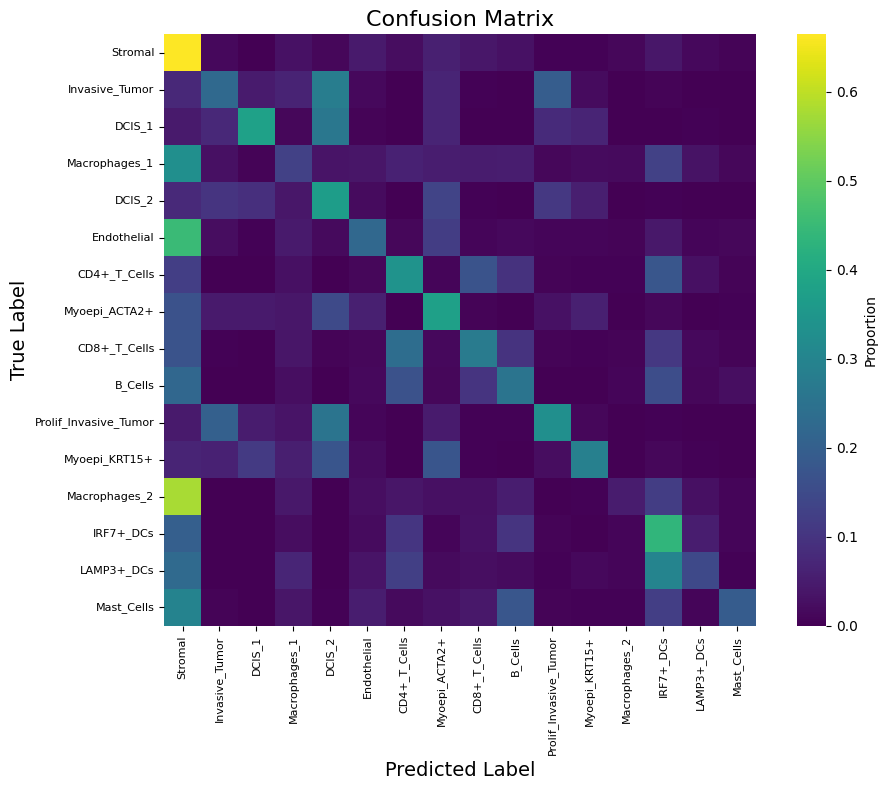

  L2 macro AUROC (OOF): 0.8536
  ROC colors: xenium_brca_fine (aligned with dataset spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/roc_internal_level2_oof.pdf


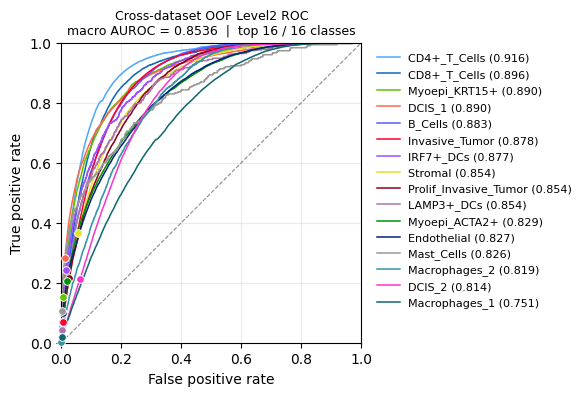


[Three-level internal] confusion matrices → /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial

L2 celltype
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/conf_matrix_level2.pdf


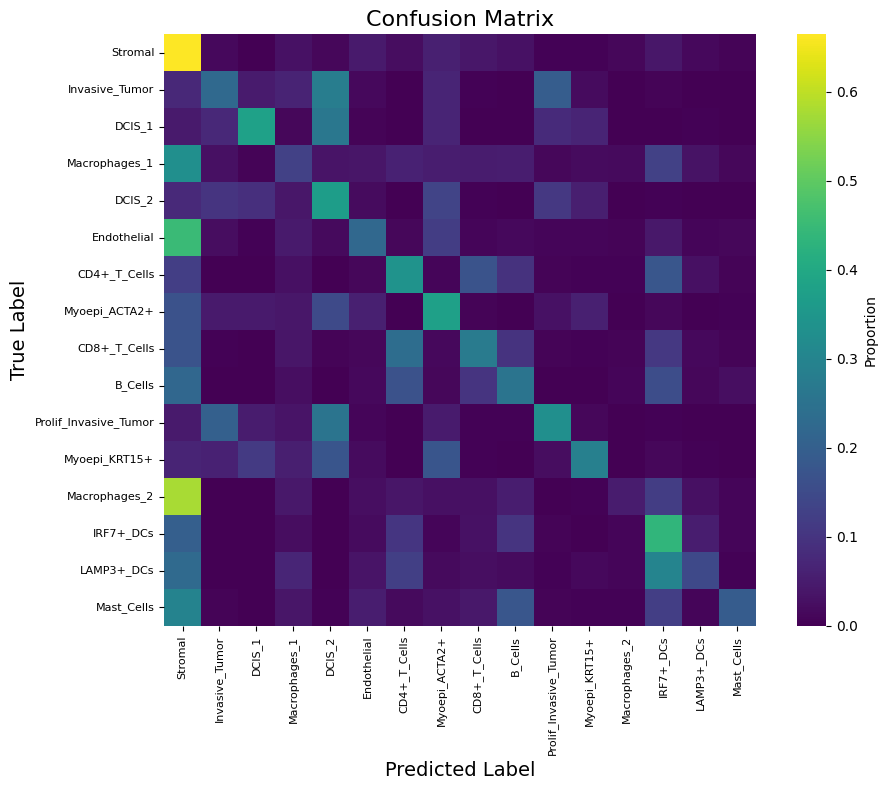


L1 lineage (L2→L1 agg)
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/conf_matrix_level1.pdf


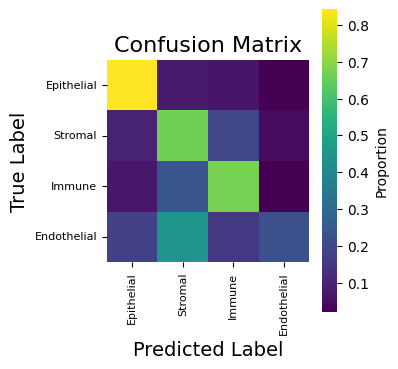


L1 lineage (L1 head)
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/conf_matrix_level1_L1head.pdf


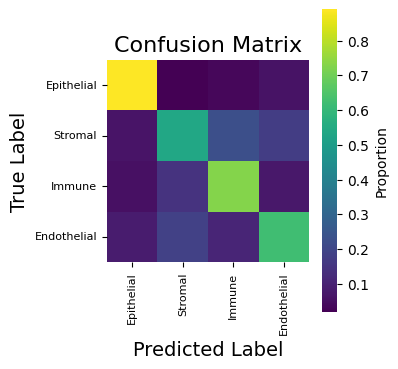


L12 sublineage
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/conf_matrix_level12.pdf


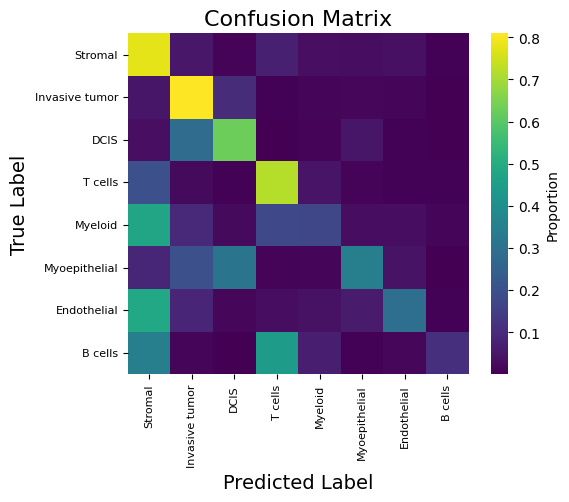

Skip L3 CNiche: no val_preds_level3 (re-run ablation cell after reload model/base)
Skip L4 TNiche: no val_preds_level4 (re-run ablation cell after reload model/base)
L1 agg vs L1 head agreement: 0.2983307813002136
Saved: conf_matrix_level2 / level1 / level12 (+ L1head if available)


In [ ]:
# L2 OOF needs group-CV LP. CLI-only load has no val_preds — skip OOF.
if pooled_ctx.g.get("val_preds") is not None:
    brca_cli.step_pooled_he_validate(pooled_ctx)
else:
    print("SKIP_POOLED_TRAIN: skip OOF HE validate (no LP). Using loaded checkpoint for in-sample plots.")

# Extra: L1 + L12 confusion from the loaded deployment model on all pooled cells
g = pooled_ctx.g
_nbr = g.get("spatial_neighbor_index")
ensure_lp_extra_insample_preds(
    g["model"],
    scaler,
    cv_data,
    device,
    predict_all_label_heads,
    g,
    neighbor_index=_nbr,
)

g["class_names"] = class_names
g["class_names_level1"] = class_names_level1
g["class_names_level12"] = class_names_level12

print("\n[Three-level internal] confusion matrices →", pooled_result_dir)
plot_he_confusion_matrices(plot_confusion_matrix, pooled_result_fig, cv_data, g)
print("Saved: conf_matrix_level2 / level1 / level12 (+ L1head if available)")


## 4. StarDist predict (each dataset) — three levels

For each sample with `{sample}_matched_features_stardist.h5ad`:

Outputs under `Results/{save_result}/stardist/{sample}/`:
- Spatial: `celltype_pred_stardist_level{2,1,12}.jpg`
- ROC: `roc_stardist_level{2,1,1_L1head,12}.pdf`
- Metrics (L2): `validation_external_stardist_matched_*.csv`


### Run StarDist one level at a time

`step_pooled_stardist(pooled_ctx)` without `levels=` runs **all three heads** (L2, L1, L12).

To run a single tier, pass e.g. `levels=["l2"]`. Valid keys: `l2`, `l1`, `l12`.

- **L2 only** writes `validation_external_stardist_matched_*.csv`.
- Other tiers write spatial / ROC / AUROC table for that head.
- Optional: `samples=POOLED_SAMPLES[:1]` to test on one region first.


In [ ]:
import importlib
importlib.reload(brca_cli)

from uni_label_cv_helpers import make_pooled_stardist_result_fig

_TIER_CHECKS = {
    "l2": ("L2 celltype (final_CT)", "stardist_pred_level2", "roc_stardist_level2"),
    "l1": ("L1 lineage (final_lineage)", "stardist_pred_level1", "roc_stardist_level1"),
    "l12": ("L12 sublineage (final_sublineage)", "stardist_pred_level12", "roc_stardist_level12"),
}


def check_stardist_level(level, sample=None):
    # Print spatial/ROC file status for one tier on one sample.
    demo = sample or POOLED_SAMPLES[0]
    title, spatial_key, roc_key = _TIER_CHECKS[level.lower()]
    rf, _ = make_pooled_stardist_result_fig(DATA_ROOT, demo, save_result)
    sp, rc = rf(spatial_key), rf(roc_key)
    print(
        f"{title} ({demo}): "
        f"spatial={'OK' if Path(sp).is_file() else 'MISSING'} | "
        f"ROC={'OK' if Path(rc).is_file() else 'MISSING'}"
    )


def ensure_stardist_h5ads(samples=None, build=True):
    # Build / refresh {sample}_matched_features_stardist.h5ad when missing or
    # older than the GT StarDist CSV (e.g. after LY DCIS_1/2 rematch).
    samples = list(samples) if samples is not None else list(POOLED_SAMPLES)
    n_rebuild = 0
    for s in samples:
        p = CASES_ROOT / s / f"{s}_matched_features_stardist.h5ad"
        csv_p = CASES_ROOT / s / f"{s}_cells_matched_by_stardist.csv"
        stale = (
            p.is_file()
            and csv_p.is_file()
            and csv_p.stat().st_mtime > p.stat().st_mtime
        )
        if p.is_file() and not stale:
            continue
        n_rebuild += 1
        if not build:
            why = "STALE vs CSV" if stale else "MISSING"
            print(f"  {why} StarDist h5ad: {p}")
            continue
        print(
            f"{'Refreshing stale' if stale else 'Building'} StarDist h5ad for {s} ...",
            flush=True,
        )
        ctx = brca_cli.RunContext(
            sample=s,
            cases_root=CASES_ROOT,
            python_root=Path(path),
            therapy_data=s,
            therapy_model=brca_cli.DEFAULT_THERAPY_MODEL,
            save_result="result",
            device=device,
            seed=SEED,
            match_tolerance=1.0,
            column_rename=dict(brca_cli.HCC_COLUMN_RENAME),
            force_rebuild_h5ad=bool(stale),
            input_dim=None,
            hidden_dims=POOLED_HIDDEN_DIMS,
            cv_k=5,
            stratify_target="joint",
            patience=10,
            max_epochs=50,
            train_batch_size=4096,
            resume_from_checkpoints=True,
            ablation_tag=POOLED_ABLATION_TAG,
            hce_w1=1.0, hce_w2=2.0, hce_w12=1.0, hce_w_l12head=1.0, hce_w_l3=1.0, hce_w_l4=1.0,
            build_stardist_h5ad=True,
            acq_id=_acq_map[s],
            stardist_root=brca_cli.DEFAULT_STARDIST_ROOT,
            use_spatial_context=POOLED_USE_SPATIAL,
            spatial_k=POOLED_SPATIAL_K,
            spatial_mode=POOLED_SPATIAL_MODE,
        )
        brca_cli._ensure_stardist_h5ad(ctx)
    print(
        f"StarDist h5ad: {len(samples) - n_rebuild} up-to-date, "
        f"built/refreshed {n_rebuild}"
    )


ensure_stardist_h5ads()


Loading dependencies...
Refreshing stale StarDist h5ad for rep1 ...
[StarDist h5ad] building matched features...
Loading celltype Ground Truth ...
  Column rename applied: {'final_CT': 'celltype', 'final_sublineage': 'celltype_level12', 'final_lineage': 'celltype_level1'}
  Loaded 146878 cells
  Cell types: 16 unique types

Loading HIPT embeddings (full scan: 252,158 .pth files, cap=400,000; skipping selective path probe).
  Loading embeddings...


Loading .pth files (workers=16): 100%|██████████| 252158/252158 [04:44<00:00, 886.41it/s] 


  Successfully loaded 252158 embeddings
  Embedding dimension: (1024,)

Matching embeddings with celltype data (this may take a few minutes)...
  Using specified coordinates: centroid_x, centroid_y
  Building KDTree for embeddings: 252,158 points
  KDTree matched 146,878 / 146,878 cells (100.00%).
  Matched 146878 cells out of 146878
  Match rate: 100.00%
  ✓ Saved matched h5ad to /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Cases/rep1/rep1_matched_features_stardist.h5ad (146,878 cells × 1024 features)
  → 146,878 cells
StarDist h5ad: 1 up-to-date, built/refreshed 1


### L2 celltype / final_CT (StarDist)



[Pooled StarDist] levels=['l2'] | 2 datasets
Loading best model for StarDist prediction...
  Checkpoint file: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/cross_dataset_cv/D_emph_L2_spatial_brca/best_mlp_gpu.pt
  Using provided hidden_dims: [1024, 512, 256]
✓ StarDist model loaded
  Spatial inference: enabled (neighbor_index shape=(146878, 8))
  Loading data from matched_features_path...
  ✓ Loaded X from /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Cases/rep1/rep1_matched_features_stardist.h5ad: (146878, 1024)
  ✓ Loaded y from /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Cases/rep1/rep1_matched_features_stardist.h5ad: (146878,), dtype: object
  ⚠ prediction_only=True: Labels will be used for visualization only, not for evaluation.
  ✓ Keeping labels as strings for visualization (no encoding needed)
  ✓ Scaled X using provided scaler
  X_all_scaled shape: (146878, 1024)
  No labels available - prediction mode only
X_all_scaled:  (146

Predicting: 100%|██████████| 144/144 [00:05<00:00, 27.03it/s]



Prediction completed:
  Total predictions: 146878
  Predicted classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
  ✓ Using original labels for visualization: 146878 labels
  ✓ Computed metrics in prediction_only mode from aligned true labels: acc=0.3996, macro_f1=0.3015, weighted_f1=0.4190

Preparing spatial distribution plot...
  Matching predictions with coordinates...
  ✓ Loaded coordinates from /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Cases/rep1/rep1_matched_features_stardist.h5ad: (146878, 2)
  Coordinates shape: (146878, 2)
  Predictions shape: (146878,)
  ✓ Created prediction DataFrame with 146878 cells

Plotting spatial distribution of PREDICTED level2 cell types...
Number of valid data points: 146878
Number of cell types: 16


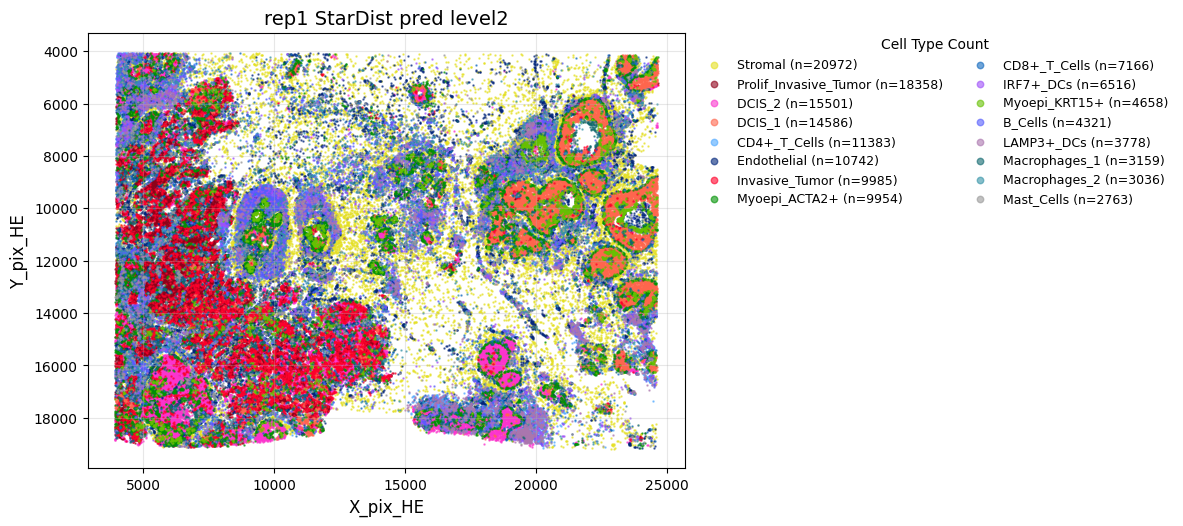


Plotting spatial distribution of TRUE level2 cell types...
Number of valid data points: 146878
Number of cell types: 16


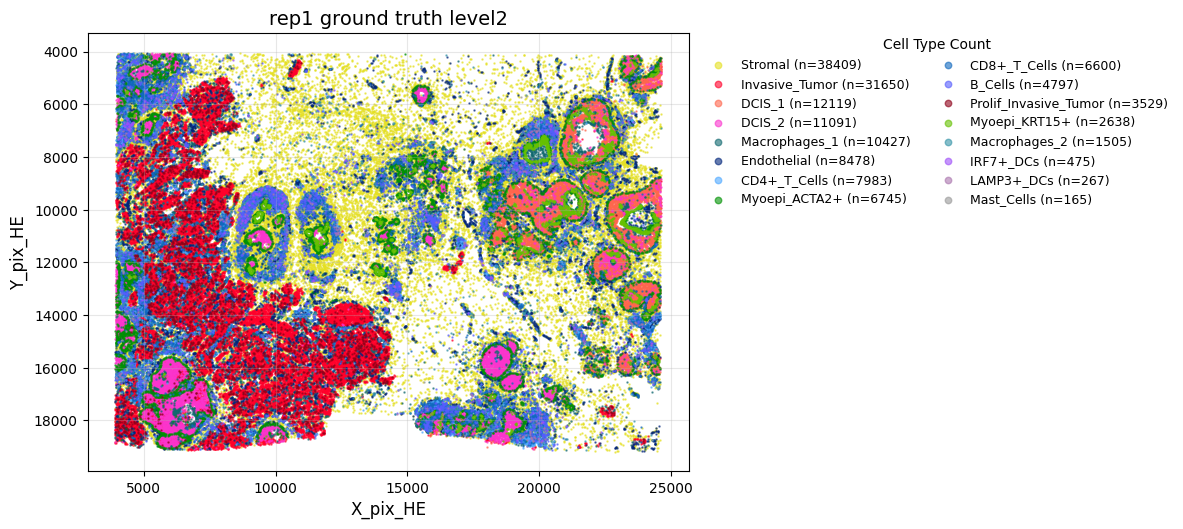

  ROC colors: xenium_brca_fine (aligned with dataset spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/stardist/rep1/roc_stardist_level2.pdf


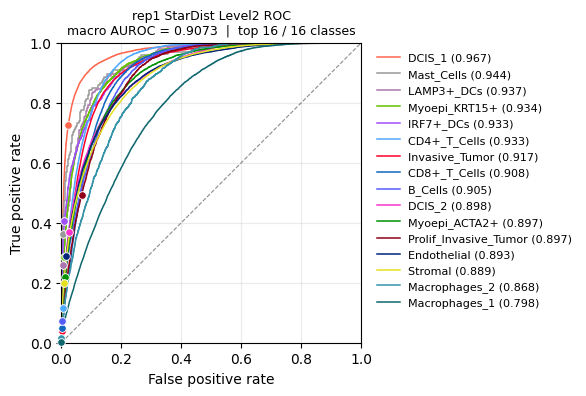

  rep1: StarDist L2 macro AUROC = 0.9073
Skip L3 CNiche: missing preds_l3
Skip L4 TNiche: missing preds_l4
Current run metrics:
             timestamp           therapy_data  best_epoch hce_lambda  hce_w1  \
0  2026-09-07 22:30:21  rep1_stardist_matched           0       None     1.0   

   hce_w2  hce_w12  hce_w_l12head  hce_w_l3  hce_w_l4  ...  \
0     2.0      1.0            1.0       1.0       1.0  ...   

   insample_l12_macro_f1  insample_l12_weighted_f1  num_l1_head_classes  \
0               0.359201                  0.433958                    4   

   num_l12_classes  insample_l2_macro_auc  insample_l1_macro_auc  \
0                8               0.907285               0.918362   

   insample_l1_head_macro_auc  insample_l12_macro_auc  val_l2_macro_auc  \
0                     0.85027                0.826209          0.907285   

   val_l1_macro_auc  
0          0.918362  

[1 rows x 38 columns]

Saved comparison table to: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA

Predicting: 100%|██████████| 96/96 [00:02<00:00, 33.07it/s]



Prediction completed:
  Total predictions: 98140
  Predicted classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
  ✓ Using original labels for visualization: 98140 labels
  ✓ Computed metrics in prediction_only mode from aligned true labels: acc=0.3009, macro_f1=0.2178, weighted_f1=0.3109

Preparing spatial distribution plot...
  Matching predictions with coordinates...
  ✓ Loaded coordinates from /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Cases/rep2/rep2_matched_features_stardist.h5ad: (98140, 2)
  Coordinates shape: (98140, 2)
  Predictions shape: (98140,)
  ✓ Created prediction DataFrame with 98140 cells

Plotting spatial distribution of PREDICTED level2 cell types...
Number of valid data points: 98140
Number of cell types: 16


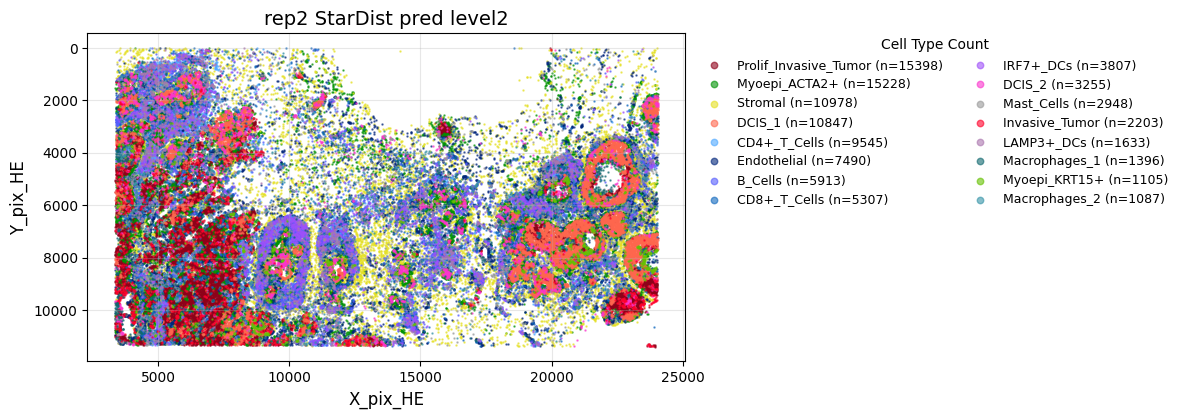


Plotting spatial distribution of TRUE level2 cell types...
Number of valid data points: 98140
Number of cell types: 16


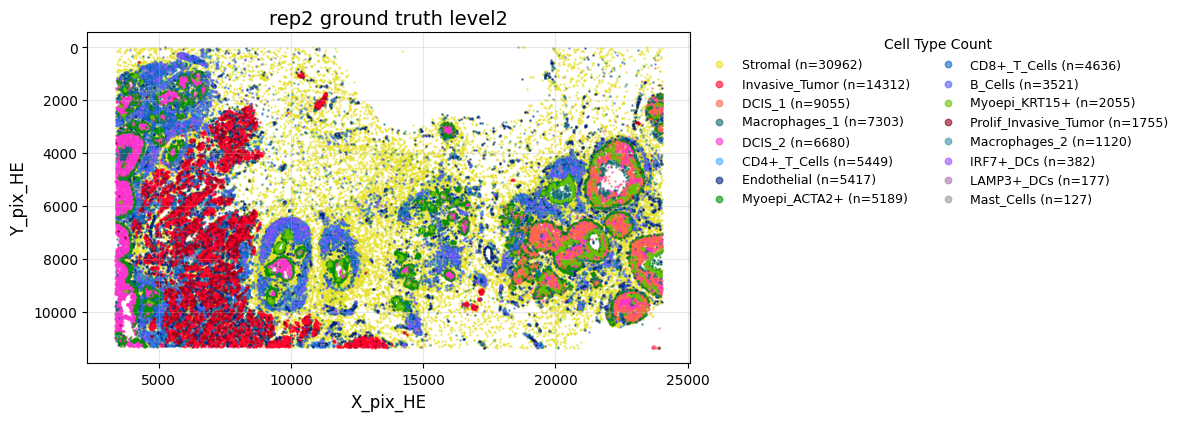

  ROC colors: xenium_brca_fine (aligned with dataset spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/stardist/rep2/roc_stardist_level2.pdf


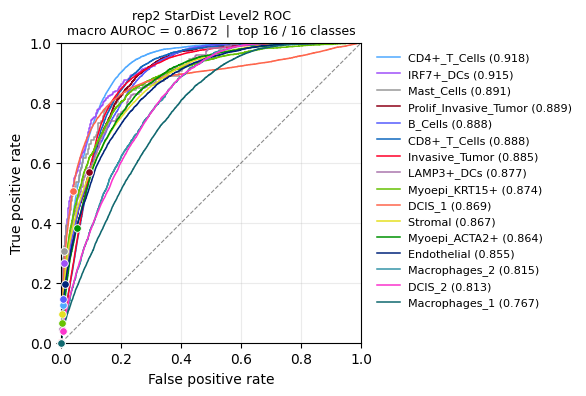

  rep2: StarDist L2 macro AUROC = 0.8672
Skip L3 CNiche: missing preds_l3
Skip L4 TNiche: missing preds_l4
Current run metrics:
             timestamp           therapy_data  best_epoch hce_lambda  hce_w1  \
0  2026-09-07 22:30:35  rep2_stardist_matched           0       None     1.0   

   hce_w2  hce_w12  hce_w_l12head  hce_w_l3  hce_w_l4  ...  \
0     2.0      1.0            1.0       1.0       1.0  ...   

   insample_l12_macro_f1  insample_l12_weighted_f1  num_l1_head_classes  \
0               0.357979                  0.414419                    4   

   num_l12_classes  insample_l2_macro_auc  insample_l1_macro_auc  \
0                8               0.867218                0.89708   

   insample_l1_head_macro_auc  insample_l12_macro_auc  val_l2_macro_auc  \
0                     0.85263                0.828623          0.867218   

   val_l1_macro_auc  
0           0.89708  

[1 rows x 38 columns]

Saved comparison table to: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA

In [ ]:
brca_cli.step_pooled_stardist(pooled_ctx, levels=["l2"])
check_stardist_level("l2")


### L1 lineage / final_lineage (StarDist)



[Pooled StarDist] levels=['l1'] | 2 datasets
Loading best model for StarDist prediction...
  Checkpoint file: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/cross_dataset_cv/D_emph_L2_spatial_brca/best_mlp_gpu.pt
  Using provided hidden_dims: [1024, 512, 256]
✓ StarDist model loaded
Number of valid data points: 146878
Number of cell types: 4


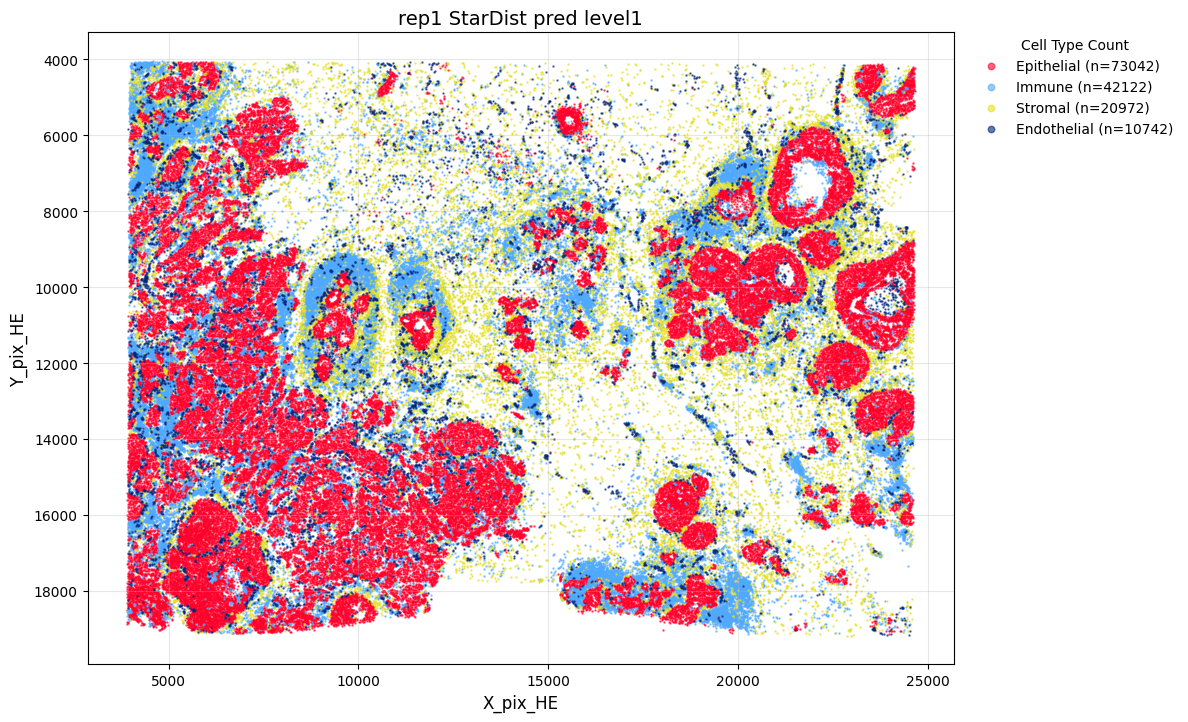

  Saved level1 predicted spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/stardist/rep1/celltype_pred_stardist_level1.jpg
Number of valid data points: 146878
Number of cell types: 4


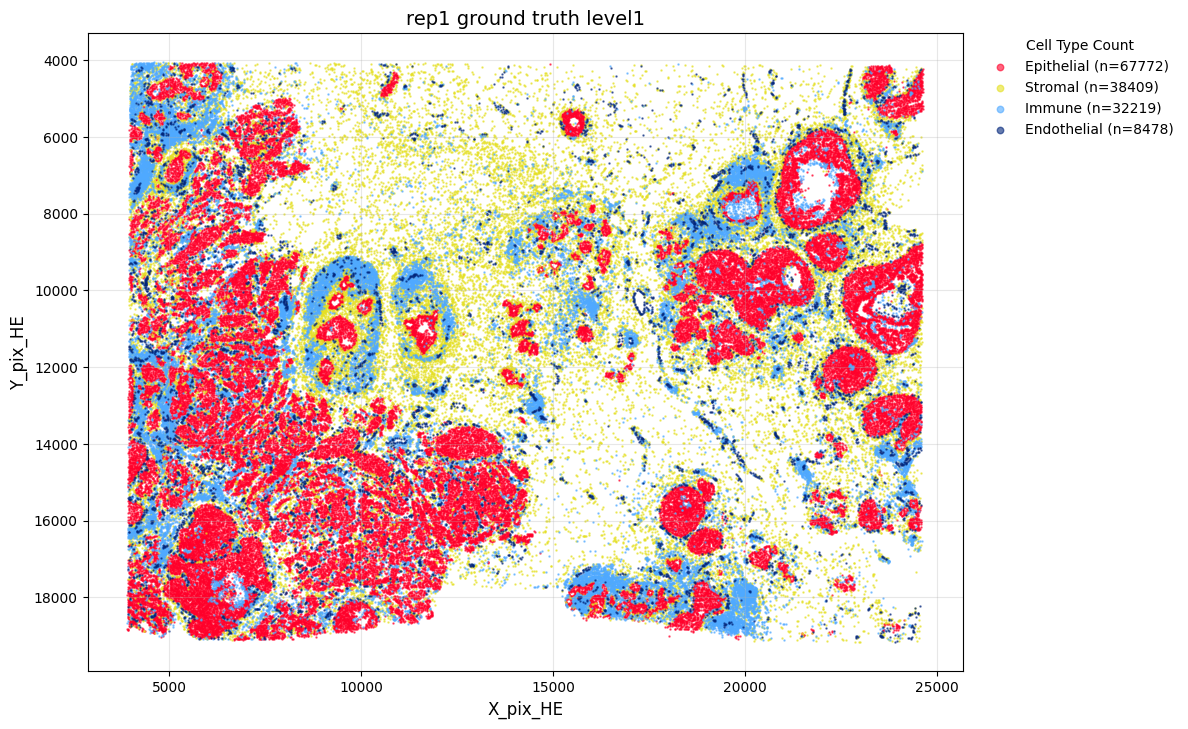

  ROC colors: xenium_brca_coarse (aligned with dataset spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/stardist/rep1/roc_stardist_level1.pdf


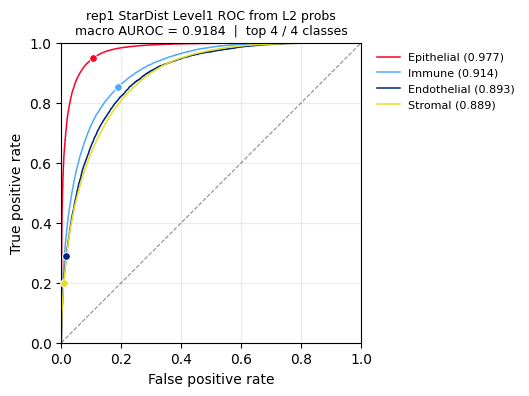

Saved StarDist L1 AUROC table: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/stardist/rep1/validation_external_stardist_matched_AUROC_level1.csv (146,878 cells; prob_0..prob_3 match class_names order)
  Class name order: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/stardist/rep1/validation_external_stardist_matched_AUROC_level1_class_names.csv
Loading best model for StarDist prediction...
  Checkpoint file: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/cross_dataset_cv/D_emph_L2_spatial_brca/best_mlp_gpu.pt
  Using provided hidden_dims: [1024, 512, 256]
✓ StarDist model loaded
Number of valid data points: 98140
Number of cell types: 4


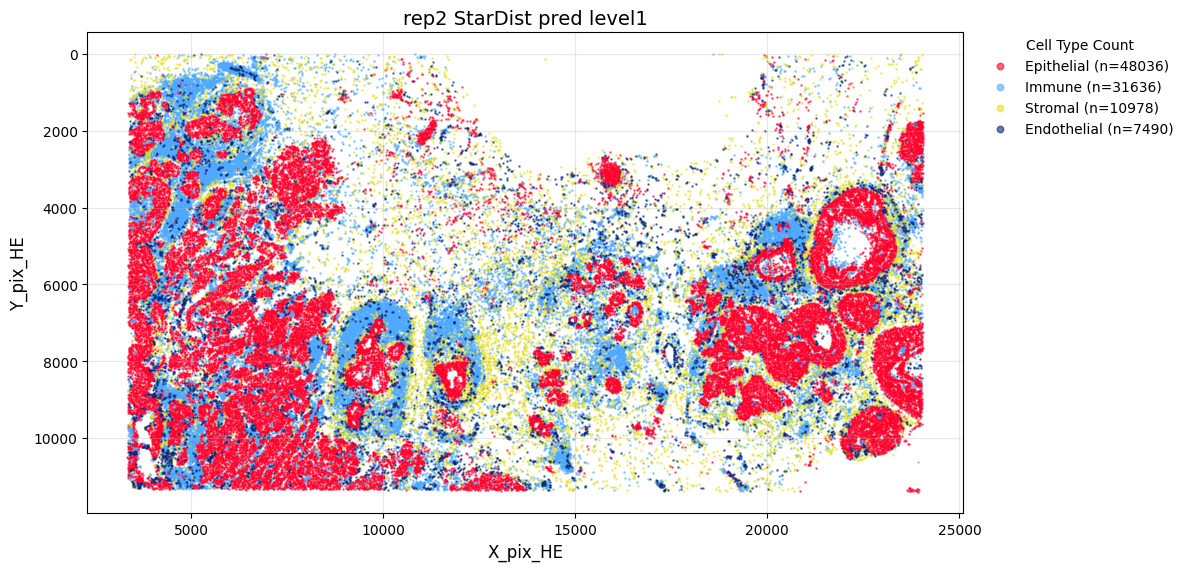

  Saved level1 predicted spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/stardist/rep2/celltype_pred_stardist_level1.jpg
Number of valid data points: 98140
Number of cell types: 4


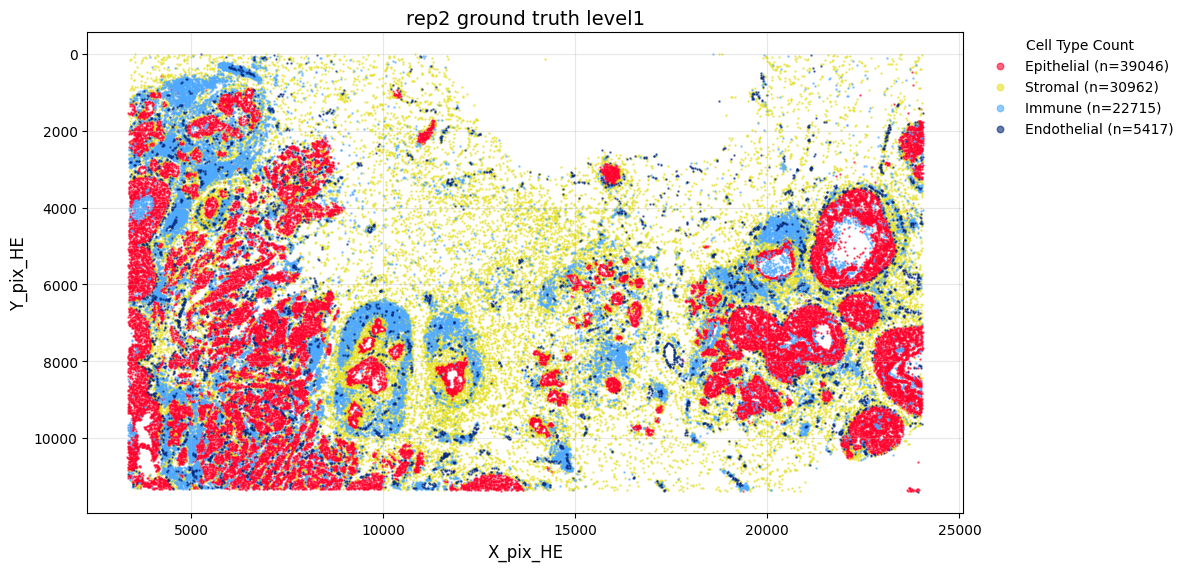

  ROC colors: xenium_brca_coarse (aligned with dataset spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/stardist/rep2/roc_stardist_level1.pdf


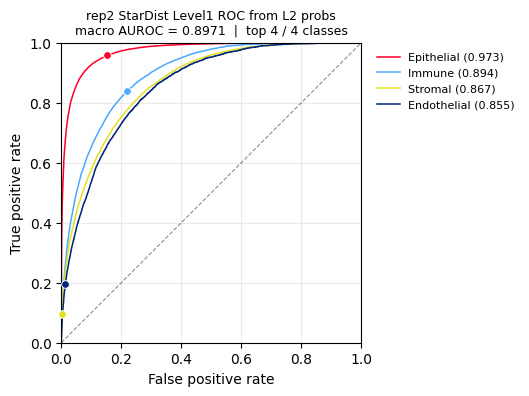

Saved StarDist L1 AUROC table: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/stardist/rep2/validation_external_stardist_matched_AUROC_level1.csv (98,140 cells; prob_0..prob_3 match class_names order)
  Class name order: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/stardist/rep2/validation_external_stardist_matched_AUROC_level1_class_names.csv
L1 lineage (final_lineage) (rep1): spatial=OK | ROC=OK


In [ ]:
brca_cli.step_pooled_stardist(pooled_ctx, levels=["l1"])
check_stardist_level("l1")


### L12 sublineage / final_sublineage (StarDist)


In [ ]:
brca_cli.step_pooled_stardist(pooled_ctx, levels=["l12"])
check_stardist_level("l12")



[Pooled StarDist] levels=['l12'] | 2 datasets
Loading best model for StarDist prediction...
  Checkpoint file: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/cross_dataset_cv/D_emph_L2_spatial_brca/best_mlp_gpu.pt
  Using provided hidden_dims: [1024, 512, 256]
✓ StarDist model loaded

L12 sublineage (StarDist)
Number of valid data points: 146878
Number of cell types: 8


In [ ]:
# Summary check for all three tiers on first sample
print(f"StarDist outputs: {pooled_result_dir / 'stardist'}")
for level in ("l2", "l1", "l12"):
    check_stardist_level(level)


StarDist outputs: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/stardist
L2 celltype (final_CT) (rep1): spatial=OK | ROC=OK
L1 lineage (final_lineage) (rep1): spatial=OK | ROC=OK
L12 sublineage (final_sublineage) (rep1): spatial=OK | ROC=OK


In [ ]:
# Optional: inspect L2 metrics / AUROC CSV for one sample
_demo = POOLED_SAMPLES[0]
_rf, _ = make_pooled_stardist_result_fig(DATA_ROOT, _demo, save_result)
_metrics = _rf("validation_external_stardist_matched_metrics")
_auroc = _auroc_csv_path_from_metrics(_metrics)
print(f"Demo: {_demo}")
print(" metrics:", _metrics)
print(" AUROC:", _auroc)
if Path(_metrics).is_file():
    display(pd.read_csv(_metrics).tail(1).T)


Demo: rep1
 metrics: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/stardist/rep1/validation_external_stardist_matched_metrics.csv
 AUROC: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/stardist/rep1/validation_external_stardist_matched_AUROC.csv


,3
timestamp,2026-09-07 22:30:21
therapy_data,rep1_stardist_matched
best_epoch,0
hce_lambda,NaN
hce_w1,1.0
hce_w2,2.0
hce_w12,1.0
hce_w_l12head,1.0
hce_w_l3,1.0
hce_w_l4,1.0


### L1 / L12 — detailed file list


In [ ]:
# Inspect L1 + L12 outputs for one sample
_demo = POOLED_SAMPLES[0]
_rf, _ = make_pooled_stardist_result_fig(DATA_ROOT, _demo, save_result)
_tiers = {
    "L1": ("stardist_pred_level1", "roc_stardist_level1", "roc_stardist_level1_L1head"),
    "L12": ("stardist_pred_level12", "stardist_true_level12", "roc_stardist_level12"),
}
for tier, keys in _tiers.items():
    print(f"\n{tier}:")
    for key in keys:
        p = Path(_rf(key))
        print(f"  {'✓' if p.is_file() else '✗'} {p.name}")



L1:
  ✓ celltype_pred_stardist_level1.jpg
  ✓ roc_stardist_level1.pdf
  ✗ roc_stardist_level1_L1head.pdf

L12:
  ✓ celltype_pred_stardist_level12.jpg
  ✓ celltype_true_stardist_level12.jpg
  ✓ roc_stardist_level12.pdf


## 5. StarDist predict on all nuclei of rep1/rep2 StarDist_Segment

Unlike **§4**, which evaluates matched GT-annotated nuclei with ground truth and AUROC, this section uses the UNI embedding to predict **every StarDist nucleus** in each BRCA replicate.

Build each input with:

`conda run --no-capture-output -n SeededNTM python -u code/Xenium_brca/transer_embedding_label_h5ad.py --sample {sample} --steps stardist_all_h5ad`

**Input:** `data/Xemium/BRCA/Cases/{sample}/{sample}_all_features_stardist.h5ad`

**Output:** `data/Xemium/BRCA/Results/{save_result}/stardist/{sample}/{sample}_all_features_stardist_label.h5ad`

The pooled BRCA checkpoint predicts three heads only: `l2` (`final_CT`), `l12` (`final_sublineage`), and `l1` (`final_lineage`). The class-name order for each probability head is stored in `adata.uns['pred_prob_class_names']`.

There is no matched-ground-truth AUROC here because the prediction covers all StarDist nuclei. Spatial-context models build their neighbor graph from the StarDist centroids. Run **§2** first to create the required pooled checkpoint.

After inference, the next cells plot pred-only maps: `{sample}_stardist_pred_{l2,l12,l1}.jpg` plus an overview JPG.


```python
conda run --no-capture-output -n SeededNTM python -u \
code/Xenium_brca/transer_embedding_label_h5ad.py \
--steps stardist_all_h5ad
```


In [ ]:
# Requires pooled_ctx.g from §2 and uses the pooled BRCA three-head checkpoint.
# Each sample needs {sample}_all_features_stardist.h5ad in its BRCA Cases directory.
from uni_label_cv_helpers import stardist_all_label_h5ad_path

if "BEST_MLP_CHECKPOINT" not in pooled_ctx.g:
    raise RuntimeError("Run §2 (step_pooled_train) first.")

brca_cli.step_pooled_stardist_all(pooled_ctx)

print(f"StarDist-all label h5ads → {pooled_result_dir / 'stardist'}")
for sample in POOLED_SAMPLES[:5]:
    out = stardist_all_label_h5ad_path(DATA_ROOT, sample, save_result)
    if out.is_file():
        print(f"  {sample}: {out.name}")
if len(POOLED_SAMPLES) > 5:
    print(f"  ... +{len(POOLED_SAMPLES) - 5} more samples")



[Pooled StarDist all nuclei] 2 datasets
Loading best model for StarDist prediction...
  Checkpoint file: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/cross_dataset_cv/D_emph_L2_spatial_brca/best_mlp_gpu.pt
  Using provided hidden_dims: [1024, 512, 256]
✓ StarDist model loaded
  rep1: saved rep1_all_features_stardist_label.h5ad (252,158 cells; 28 prob columns; heads=['l1', 'l12', 'l2'])
Loading best model for StarDist prediction...
  Checkpoint file: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/cross_dataset_cv/D_emph_L2_spatial_brca/best_mlp_gpu.pt
  Using provided hidden_dims: [1024, 512, 256]
✓ StarDist model loaded
  rep2: saved rep2_all_features_stardist_label.h5ad (245,246 cells; 28 prob columns; heads=['l1', 'l12', 'l2'])
StarDist-all label h5ads → /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/stardist
  rep1: rep1_all_features_stardist_label.h5ad
  rep2: rep2_all_features_sta

In [ ]:
import anndata as ad

# Inspect the first pooled BRCA sample without loading the full matrix into memory.
_demo = POOLED_SAMPLES[0]
_demo_h5ad = stardist_all_label_h5ad_path(DATA_ROOT, _demo, save_result)
print(f"Demo: {_demo}\n  {_demo_h5ad}")
if _demo_h5ad.is_file():
    _a = ad.read_h5ad(_demo_h5ad, backed="r")
    try:
        prob_cols = [c for c in _a.obs.columns if "_prob_" in c]
        print(f"  n_obs={_a.n_obs:,}  prob columns={len(prob_cols)}")
        print(f"  heads in uns: {list(_a.uns.get('pred_prob_class_names', {}).keys())}")
        print(f"  sample obs cols: {list(_a.obs.columns[:8])} ...")
    finally:
        # Close the backed AnnData file handle after inspection.
        _a.file.close()
else:
    print("  (file not found — run the cell above first)")


Demo: rep1
  /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/stardist/rep1/rep1_all_features_stardist_label.h5ad
  n_obs=252,158  prob columns=28
  heads in uns: ['l1', 'l12', 'l2']
  sample obs cols: ['cell_id', 'centroid_x', 'centroid_y', 'probability', 'l2_prob_0', 'l2_prob_1', 'l2_prob_2', 'l2_prob_3'] ...


### Plot all-nuclei predictions (L2 / L12 / L1)

Pred-only spatial maps from `{sample}_all_features_stardist_label.h5ad` (all StarDist nuclei, **no GT**).

**JPGs** (next to each label h5ad):
`Results/{save_result}/stardist/{sample}/{sample}_stardist_pred_{l2,l12,l1}.jpg`

These are distinct from §4 matched plots (`celltype_pred_stardist_level*.jpg`).


In [ ]:
# Pred-only spatial maps for every StarDist nucleus (from §5 label h5ads).
from uni_label_cv_helpers import (
    plot_stardist_label_spatial_maps,
    plot_stardist_label_spatial_overview,
    stardist_all_label_h5ad_path,
)

_ALL_HEADS = ("l2", "l12", "l1")
print(f"Plotting all-nuclei StarDist preds × {_ALL_HEADS}")
all_spatial = plot_stardist_label_spatial_maps(
    DATA_ROOT,
    POOLED_SAMPLES,
    save_result,
    label_h5ad_path_fn=stardist_all_label_h5ad_path,
    heads=_ALL_HEADS,
    pan_organ=brca_cli.PAN_ORGAN,
    show=False,
    missing_error="No all-nuclei label h5ads. Run §5 step_pooled_stardist_all first.",
)
print(f"Plotted {len(all_spatial)} sample(s).")


Plotting all-nuclei StarDist preds × ('l2', 'l12', 'l1')
  rep1: n=252,158
Number of valid data points: 252158
Number of cell types: 16
  Saved predicted spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/stardist/rep1/rep1_stardist_pred_l2.jpg
  saved rep1_stardist_pred_l2.jpg
Number of valid data points: 252158
Number of cell types: 8
  Saved predicted spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/stardist/rep1/rep1_stardist_pred_l12.jpg
  saved rep1_stardist_pred_l12.jpg
Number of valid data points: 252158
Number of cell types: 4
  Saved predicted spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/stardist/rep1/rep1_stardist_pred_l1.jpg
  saved rep1_stardist_pred_l1.jpg
  rep2: n=245,246
Number of valid data points: 245246
Number of cell types: 16
  Saved predicted spatial plot: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_s

In [ ]:
# Compact overview: samples × L2/L12/L1
_overview_path = pooled_result_dir / "stardist" / "stardist_all_pred_overview.jpg"
plot_stardist_label_spatial_overview(
    all_spatial,
    heads=_ALL_HEADS,
    pan_organ=brca_cli.PAN_ORGAN,
    save_path=_overview_path,
    show=True,
    suptitle=f"BRCA all StarDist nuclei — {save_result}",
)
print(f"Overview → {_overview_path}")


In [ ]:
## §4 batch only (matched GT nuclei + AUROC) — NOT all-nuclei.
## For all StarDist nuclei use §5: brca_cli.step_pooled_stardist_all(pooled_ctx)
# brca_cli.step_pooled_stardist(pooled_ctx, levels=["l2", "l1", "l12"])
# for level in ("l2", "l1", "l12"):
#     check_stardist_level(level)

print("Skip by default — use per-level cells in §4, or uncomment above.")


## 6. Extra StarDist-only regions

Xenium BRCA preview has **only** annotated `rep1` and `rep2`. There is no HCC-style rest / Incomplete_Cases set. Skip this section.


In [ ]:
REST_SAMPLES_ALL = brca_cli.discover_brca_rest_samples(
    CASES_ROOT, brca_cli.DEFAULT_STARDIST_ROOT, require_h5ad=False,
)
REST_SAMPLES = brca_cli.discover_brca_rest_samples(
    CASES_ROOT, brca_cli.DEFAULT_STARDIST_ROOT, require_h5ad=True,
)
print(f"BRCA rest (unannotated StarDist-only): {len(REST_SAMPLES_ALL)}")
print("Expected: 0 for the 10x breast cancer preview.")


BRCA rest (unannotated StarDist-only): 0
Expected: 0 for the 10x breast cancer preview.


In [ ]:
print("No BRCA rest label h5ads — preview dataset is fully annotated (rep1 / rep2).")


No BRCA rest label h5ads — preview dataset is fully annotated (rep1 / rep2).


### Plot cell type

In [ ]:
print("Skip rest spatial maps — BRCA preview has no unlabeled extra regions.")


Skip rest spatial maps — BRCA preview has no unlabeled extra regions.


In [ ]:
print("Skip rest spatial overview.")


Skip rest spatial overview.


## Notes

- BRCA uses **three heads** (L2 / L12 / L1), like HCC, not lung's five-head CNiche/TNiche.
- Per-sample notebook: `BRCA_train_validate_cv_UNIlabel_single.ipynb`
- Batch CLI: `BRCA_train_validate_cv_UNIlabel.py --mode cross-dataset`
- `Unlabeled` is excluded from training (empty L12/L1 in the LY `celltype` sheet).
- L12 name `Hybrid` maps to two L0 parents; L2→L0 is 1:1.
